In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#loading of the data
dati = pd.read_csv('proj2_data/petrolio_hor.csv')

## **Analisi e creazione dei dati**

In [ ]:

dati['geopol_event_type_filled'] = dati['geopol_event_type'].fillna('none')
dati['geopol_region_filled'] = dati['geopol_region'].fillna('none')
dati['geopol_shock_direction_filled'] = dati['geopol_shock_direction'].fillna('none')
dati['geopol_severity_filled'] = dati['geopol_severity'].fillna('none')
dati['sanctions_imposing_authority_filled'] = dati['sanctions_imposing_authority'].fillna('none')

event_type_map = {'none': 0, 'diplomatic': 1, 'terror': 2, 'political': 3, 'sanctions':4, 'market':5, 'economic':6, 'military': 7}
dati['event_type_encoded'] = dati['geopol_event_type_filled'].map(event_type_map)

region_map = {'none': 0, 'Middle East': 1, 'Global': 2}
dati['region_encoded'] = dati['geopol_region_filled'].map(region_map)

shock_dir_map = {'none': 0, 'up': 1, 'down': 2}
dati['shock_dir_encoded'] = dati['geopol_shock_direction_filled'].map(shock_dir_map)

severity_map = {'none': 0, 'low': 1, 'medium': 2, 'high': 3, 'extreme': 4}
dati['severity_encoded'] = dati['geopol_severity_filled'].map(severity_map)

imposing_authority_map = {'none': 0, 'US': 1, 'EU': 2, 'UN': 3, 'US/EU': 4, 'US/EU/UN': 5}
dati['imposing_authority_encoded'] = dati['sanctions_imposing_authority_filled'].map(imposing_authority_map)

#sanc_category_map = {'asset_freeze': 1, 'trade_ban': 2, 'secondary_sanctions': 3, 'nuclear_sanctions': 4, 'comprehensive': 5, 'financial': 6, 'oil_embargo': 7, 'oil_sanctions': 8, 'partial_relief': 9 }

features = ['opec_production_mbd', 'us_rig_count', 'geopolitical_risk_index', 'iran_specific_risk_bp', 'vix_index', 
            'usd_index_dxy', 'gold_usd_oz', 'opec_spare_capacity_mbd', 'brent_risk_premium_usd', 'energy_security_index',
            'geopol_has_event', 'event_type_encoded', 'region_encoded', 'geopol_iran_involved', 'geopol_price_shock_pct', 'shock_dir_encoded',
            'geopol_duration_days', 'severity_encoded', 'geopol_strait_of_hormuz_risk', 'geopol_sanctions_related', 'geopol_military_action',
            'sanctions_has_event', 'imposing_authority_encoded', 'sanctions_gdp_impact_pct', 'sanctions_oil_sector_affected',
            'sanctions_financial_sector_affected', 'sanctions_is_relief', 'sanctions_cumulative_pressure'  
            ]

dati[features] = dati[features].fillna(0)

X_full = np.transpose(np.vstack([dati[feat] for feat in features]))
X = X_full[365:, :] #training/internal testing set
X_2026 = X_full[:365, :] #external testing set

threshold_brent = 100.0 #threshold on the price [usd]
labels_full = [int(dati['brent_usd'][i] >= threshold_brent) for i in range(len(dati['brent_usd']))]
labels = labels_full[365:] #defining the classes
labels_2026 = labels_full[:365]


## Training

In [ ]:

accuracy_CV = []
accuracy_int = []
accuracy_2026 = []
proba_int = []
proba_2026 = []

for run in range(10): #averaging the results over 10 training runs

    X_train, X_test, y_train, y_test = train_test_split(X, labels, train_size=0.82, stratify=labels)
    SC = StandardScaler() 
    scaled_X_train = SC.fit_transform(X_train)
    pca = PCA(n_components=15) 
    reduced_X_train = pca.fit_transform(scaled_X_train)
    

    k = [2, 4, 8, 16] #number of folds
    k_accuracy = []
    param_grid = {'criterion': ('gini', 'entropy'), 'n_estimators': [2, 4, 6, 8, 10, 50, 100, 150, 200, 300, 400]} #hyperparameters checked
    best_CV_model = GridSearchCV(RandomForestClassifier(), param_grid=param_grid)

    for splits in k:
        skf = StratifiedKFold(n_splits=splits, shuffle=True) #manually creates partitions
        CV_model = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=skf) #search over hyperparameters using CV
        CV_model.fit(reduced_X_train, y_train) #finds best hyperparameter on Training patterns
        k_accuracy.append(CV_model.best_score_)
        if CV_model.best_score_ == np.max(np.array(k_accuracy)):
            best_CV_model = CV_model

    accuracy_CV.append(best_CV_model.best_score_)
    
    RF = RandomForestClassifier(criterion=best_CV_model.best_params_['criterion'], n_estimators=best_CV_model.best_params_['n_estimators']) #configures SVM with best iperparameter found
    RF.fit(reduced_X_train, y_train) #training with optimized hyperparameters
    scaled_X_test = SC.transform(X_test)
    reduced_X_test = pca.transform(scaled_X_test)
    y_predict = RF.predict(reduced_X_test)
    y_predict_proba = RF.predict_proba(reduced_X_test)
    proba_int.append(y_predict_proba)

    #print(accuracy_score(y_test, y_predict))
    accuracy_int.append(accuracy_score(y_test, y_predict))

    scaled_X_2026 = SC.transform(X_2026)
    reduced_X_2026 = pca.transform(scaled_X_2026)
    y_predict_2026 = RF.predict(reduced_X_2026)
    y_predict_proba_2026 = RF.predict_proba(reduced_X_2026)
    proba_2026.append(y_predict_proba_2026)
    #print(accuracy_score(labels_2026, y_predict_2026))
    accuracy_2026.append(accuracy_score(labels_2026, y_predict_2026))

print('------------------------------------------------------------------')
print('Accuracy in CV: '+str(np.mean(accuracy_CV))+' +- '+str(np.std(accuracy_CV)))
print('Accuracy on internal testing: '+str(np.mean(accuracy_int))+' +- '+str(np.std(accuracy_int)))
print('Accuracy on 2026 data: '+str(np.mean(accuracy_2026))+' +- '+str(np.std(accuracy_2026)))

pca applied!
0.9849246231155779
1.0
pca applied!
0.9899497487437185
1.0
pca applied!
0.9874371859296482
1.0
pca applied!
0.9855527638190955
1.0
pca applied!
0.9886934673366834
1.0
pca applied!
0.9912060301507538
1.0
pca applied!
0.9861809045226131
1.0
pca applied!
0.9880653266331658
1.0
pca applied!
0.9842964824120602
1.0
pca applied!
0.9842964824120602
1.0
------------------------------------------------------------------
Accuracy in CV: 0.98785177881701 +- 0.0007930124045875615
Accuracy on internal testing: 0.9870603015075379 +- 0.002285603693299033
Accuracy on 2026 data: 1.0 +- 0.0


## Classification probabilities

In [ ]:
# INTERNAL TESTING
run_proba = []
probabilities = []

for run in range(len(proba_int)):
    
    for probs in proba_int[run]:
        run_proba.append(np.max(probs))
    probabilities.append(np.mean(run_proba))

mean_proba = np.mean(probabilities)
std_proba = np.std(probabilities)

print('Average classification probability: '+str(mean_proba)+' +- '+str(std_proba))

Average classification probability: 0.977586475532424 +- 0.00037105426415715535


In [20]:
#2026 DATA
run_proba_2026 = []
probabilities_2026 = []

for run in range(len(proba_2026)):
    
    for probs in proba_2026[run]:
        run_proba_2026.append(np.max(probs))
    probabilities_2026.append(np.mean(run_proba))

mean_proba_2026 = np.mean(probabilities_2026)
std_proba_2026 = np.std(probabilities_2026)

print('Average classification probability: '+str(mean_proba_2026)+' +- '+str(std_proba_2026))

Average classification probability: 0.9776568781407035 +- 1.1102230246251565e-16


## Principal component analysis

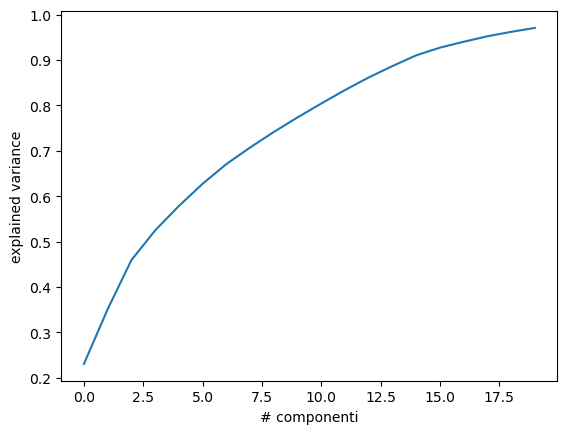

In [ ]:

cum_sum_eig = np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.arange(0, len(reduced_X_train[1])), cum_sum_eig)
plt.xlabel('# componenti')
plt.ylabel('explained variance')
plt.show()

In [9]:
for i in range(len(pca.components_)): print ([i], pca.explained_variance_ratio_[i])

[0] 0.23033091625173102
[1] 0.12072083271591333
[2] 0.10805230977864733
[3] 0.06541036716826257
[4] 0.05375164456695005
[5] 0.048995580328199555
[6] 0.04334110328799992
[7] 0.03650613913199041
[8] 0.034276551703667515
[9] 0.032087021612673745
[10] 0.030620890756217548
[11] 0.02968159917987524
[12] 0.02771788367621243
[13] 0.025182345725927067
[14] 0.023555372996662893
[15] 0.01695232642559976
[16] 0.012933728531714681
[17] 0.012103652745310271
[18] 0.00972251989835012
[19] 0.00868847938608929


In [10]:
first_pc_loading = pca.components_[0]

loadings_1 = pd.DataFrame({
    'Feature': features, 
    'Pesi': first_pc_loading,
    'Pesi_assoluti': abs(first_pc_loading) 
})

loadings_1 = loadings_1.sort_values(by='Pesi_assoluti', ascending=False)

print("Feature più importanti per la Componente 0:")
print(loadings_1.head(10))

print("")
print("------------------------------------------------------------------------------")
print("")

second_pc_loading = pca.components_[1]

loadings_2 = pd.DataFrame({
    'Feature': features, 
    'Pesi': second_pc_loading,
    'Pesi_assoluti': abs(second_pc_loading) 
})

loadings_2 = loadings_2.sort_values(by='Pesi_assoluti', ascending=False)

print("Feature più importanti per la Componente 1:")
print(loadings_2.head(10))

print("")
print("------------------------------------------------------------------------------")
print("")

third_pc_loading = pca.components_[2]

loadings_3 = pd.DataFrame({
    'Feature': features, 
    'Pesi': third_pc_loading,
    'Pesi_assoluti': abs(third_pc_loading) 
})

loadings_3 = loadings_3.sort_values(by='Pesi_assoluti', ascending=False)

print("Feature più importanti per la Componente 2:")
print(loadings_3.head(10))

Feature più importanti per la Componente 0:
                       Feature      Pesi  Pesi_assoluti
12            geopol_has_event  0.350176       0.350176
19            severity_encoded  0.338872       0.338872
14              region_encoded  0.331783       0.331783
17           shock_dir_encoded  0.328808       0.328808
13          event_type_encoded  0.320982       0.320982
18        geopol_duration_days  0.278699       0.278699
15        geopol_iran_involved  0.253893       0.253893
22      geopol_military_action  0.210147       0.210147
23         sanctions_has_event  0.208991       0.208991
24  imposing_authority_encoded  0.205631       0.205631

------------------------------------------------------------------------------

Feature più importanti per la Componente 1:
                                Feature      Pesi  Pesi_assoluti
23                  sanctions_has_event  0.394884       0.394884
24           imposing_authority_encoded  0.374553       0.374553
29        sanctions_

## Andamento Petrolio-Oro

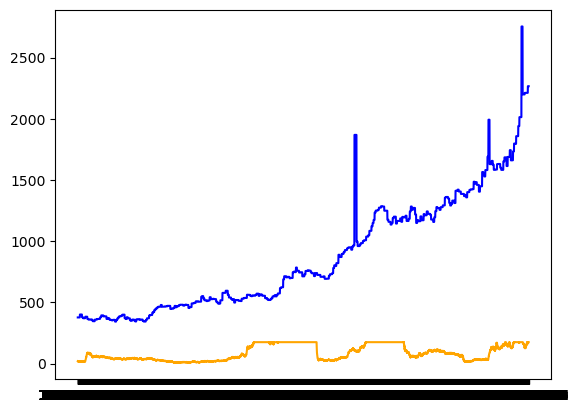

In [15]:
plt.plot(dati['date'], dati['gold_usd_oz'], color='blue')
plt.plot(dati['date'], dati['dubai_usd'], color='orange')
plt.show()